QUESTION 1

Overview:

In [ ]:
%pip install gdown
import gdown

file_id = "1qOsO1ocP9WT0pK1CMK2EDNlmqemSZID8"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "dataset.csv", quiet=False)

  Using cached gdown-5.2.1-py3-none-any.whl.metadata (5.8 kB)
Using cached gdown-5.2.1-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [gdown]


Downloading...
From: https://drive.google.com/uc?id=1qOsO1ocP9WT0pK1CMK2EDNlmqemSZID8
To: /Users/lylaliu/Desktop/ECE219P1/dataset.csv
100%|██████████| 14.5M/14.5M [00:00<00:00, 58.8MB/s]


'dataset.csv'

In [3]:
import pandas as pd

df = pd.read_csv("dataset.csv")
df.head()
df.shape

(3476, 8)

Overview: The dataset contains 3476 rows and 8 features.

Histogram (a): The total number of alpha-numeric characters per data point in the feature full_text

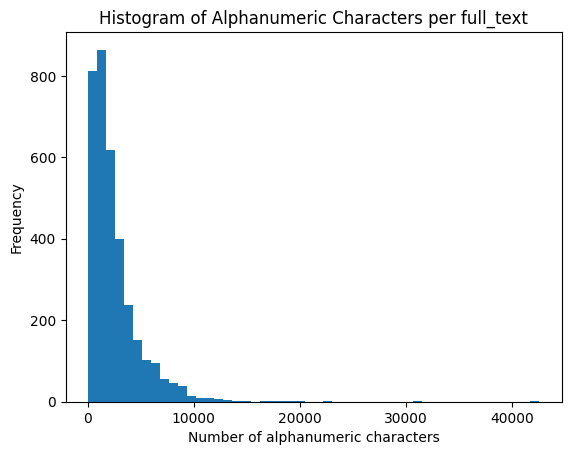

In [4]:
import re

def count_alnum(text):
    return len(re.findall(r"[A-Za-z0-9]", str(text)))

df["alnum_count"] = df["full_text"].apply(count_alnum)
df["alnum_count"].head()

import matplotlib.pyplot as plt

plt.hist(df["alnum_count"], bins=50)
plt.xlabel("Number of alphanumeric characters")
plt.ylabel("Frequency")
plt.title("Histogram of Alphanumeric Characters per full_text")
plt.show()

Histogram (b): The column leaf_label - class on the x-axis

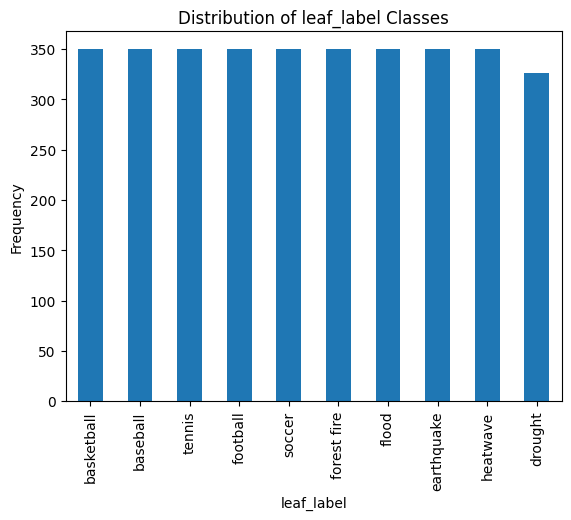

In [5]:
df["leaf_label"].value_counts().plot(kind="bar")
plt.xlabel("leaf_label")
plt.ylabel("Frequency")
plt.title("Distribution of leaf_label Classes")
plt.show()

Histogram (c): The column root_label - class on the x-axis

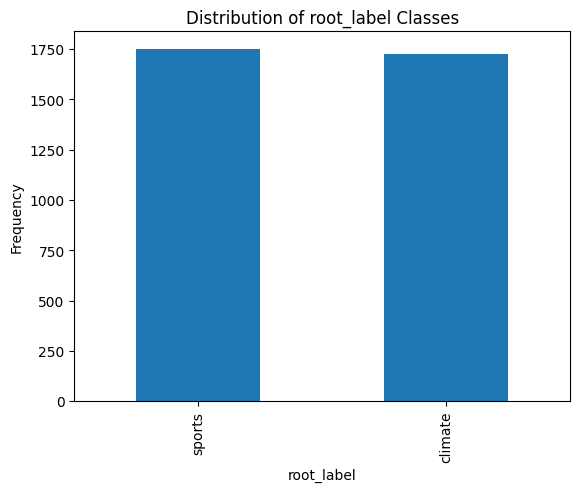

In [6]:
df["root_label"].value_counts().plot(kind="bar")
plt.xlabel("root_label")
plt.ylabel("Frequency")
plt.title("Distribution of root_label Classes")
plt.show()

Histogram interpretations:

Histogram (a): The distribution of alphanumeric character counts in full_text is right-skewed, indicating that most text samples are relatively short, while a smaller number of samples contain significantly longer text. This suggests variability in article or sentence length, which may affect downstream modeling and may require normalization or truncation.

Histogram (b): The distribution of leaf_label classes is nearly uniform, with most classes containing approximately the same number of samples. This suggests the dataset was intentionally constructed to be balanced at the leaf level, which is beneficial for training and evaluating classification models without bias toward particular classes. A slight deviation is observed for the drought class, which contains marginally fewer samples, likely due to preprocessing or filtering effects.

Histogram (c): The distribution of root_label classes is nearly balanced with samples labeled as sports and climate. This balance arises from the intentional construction of the dataset, in which each root category contains an equal number of leaf-level classes with approximately uniform sample counts. Such balance is advantageous for hierarchical classification tasks, as it prevents bias toward either top-level category during model training and evaluation.

QUESTION 2

In [7]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

from sklearn.model_selection import train_test_split

train, test = train_test_split(
    df[["full_text", "root_label", "leaf_label"]],
    test_size=0.2,
    random_state=42
)

print("Number of training samples:", train.shape[0])
print("Number of testing samples:", test.shape[0])


Number of training samples: 2780
Number of testing samples: 696


Using a fixed random seed for reproducibility, the dataset was split into training and testing sets with a test fraction of 0.2. This resulted in 2,780 training samples and 696 testing samples. The same split is reused for both the root-level (binary) and leaf-level (multiclass) classification experiments to ensure consistency across evaluations.